## Rounded Micro Domain

The micro domain is defined by a bounding box and a smooth function parameterising the floor of the micro domain. 

In [1]:
from boundary_solvers.blobs import StokesDirichletProblem
import sys
import torch
from boundary_solvers.gauss_grid_2d import *
from boundary_solvers.geometry import *
import numpy as np
import matplotlib.pyplot as plt
from util.plot_tools import *
from boundary_solvers.blobs import *
import os


path_data = "/home/emastr/github/deep-micro-slip-model/data"
path_geometries = "/home/emastr/github/deep-micro-slip-model/data/micro_geometries_boundcurv_test/"
path_torch = "/home/emastr/deep-micro-slip-model/data/micro_geometries_boundcurv_repar_256_test/"

path_fig = "/home/emastr/deep-micro-slip-model/data/figures/"
os.makedirs(path_data, exist_ok=True)
os.makedirs(path_geometries, exist_ok=True)
os.makedirs(path_torch, exist_ok=True)


## Generating a data set

Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0


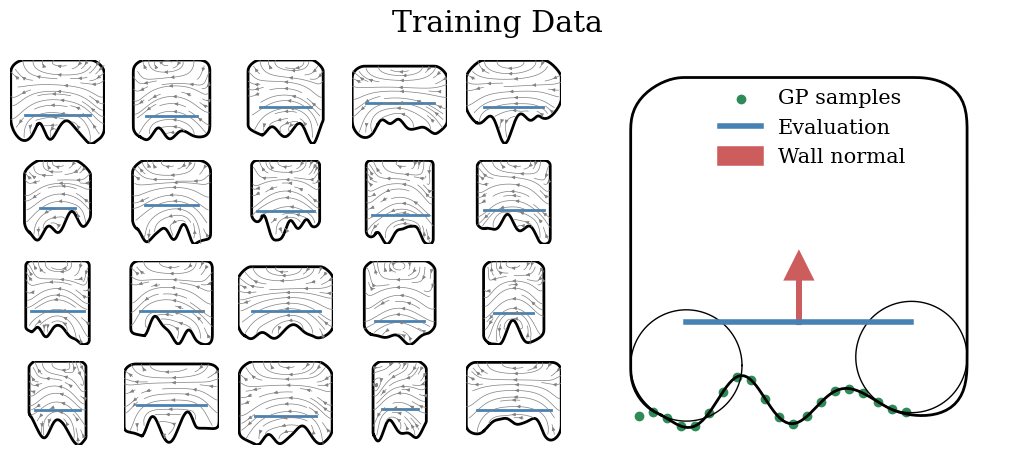

In [2]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8,8)
matplotlib.rcParams['font.size'] = 18
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(13,5))

n,m = 4,5
i0 = 0
for i in range(n*m):
    data = torch.load(f"{path_geometries}/domain_{i0 + i}.GPDomain")
    data.pop("precomp")
    data.pop("precomp_der")
    data.pop("intermediate_precomp")
    data.pop("intermediate_precomp_der")
    data.pop("error")
    geom = GPDomain.load(data)
    
    plt.subplot2grid((n,m+n), (i//m, i%m), colspan=1)
    geom.plot(ax=plt.gca(), npts=300, show_samples=False, show_rounded=False, show_hline=False, color="black")
    a, b = geom.line_left, geom.line_right
    plt.plot([np.real(a), np.real(b)], [np.imag(a), np.imag(b)], color="steelblue", linewidth=2)
    if True:#i < m:
        r1, func = geom.precompute_line_avg(derivative=0, tol=1e-10, maxiter=40, verbose=True)
        v = geom.zero_flow(r1*1j)
        condition = lambda t: v
        problem = StokesDirichletProblem(geom, condition)
        problem.solve(tol=1e-9, maxiter=40)
        problem.geometry.plot_stream(ax=plt.gca(), func=lambda z: problem.evaluate(z), apply_mask=True, color='grey', linewidth=0.5, arrowsize=0.5, density=0.5, maxlength=6.0)
        print("Done with ", i, end="\r")
        
    plt.axis("equal")
    plt.axis("off")
    
plt.subplot2grid((n,m+n), (0, m), colspan=n, rowspan=n)

data = torch.load(f"{path_geometries}/domain_{i0 + 1}.GPDomain")
data.pop("precomp")
data.pop("precomp_der")
data.pop("intermediate_precomp")
data.pop("intermediate_precomp_der")
data.pop("error")
geom = GPDomain.load(data)
geom.plot(ax=plt.gca(), npts=300, show_samples=False, show_rounded=True, show_hline=False, color="black")
plt.scatter(geom.X, geom.Y-geom.bound, color="seagreen", label="GP samples")
a, b = geom.line_left, geom.line_right
plt.plot([np.real(a), np.real(b)], [np.imag(a), np.imag(b)], color="steelblue", label="Evaluation", linewidth=4)
c = (geom.line_left + geom.line_right)/2
cx, cy = np.real(c), np.imag(c)
plt.arrow(cx, cy, 0, 0.2, head_width=0.1, head_length=0.1, fc='indianred', ec='indianred', linewidth=4, label="Wall normal")
plt.legend(frameon=False, fontsize=15, loc=[0.3, 0.7])#, loc="upper right", fontsize=12)

plt.axis("equal")
plt.axis("off")

#plt.tight_layout()
plt.suptitle("Training Data")
plt.gcf().savefig(f"{path_fig}/training_data.pdf", bbox_inches="tight")

# Convert to PyTorch Tensor

Convergence state 0


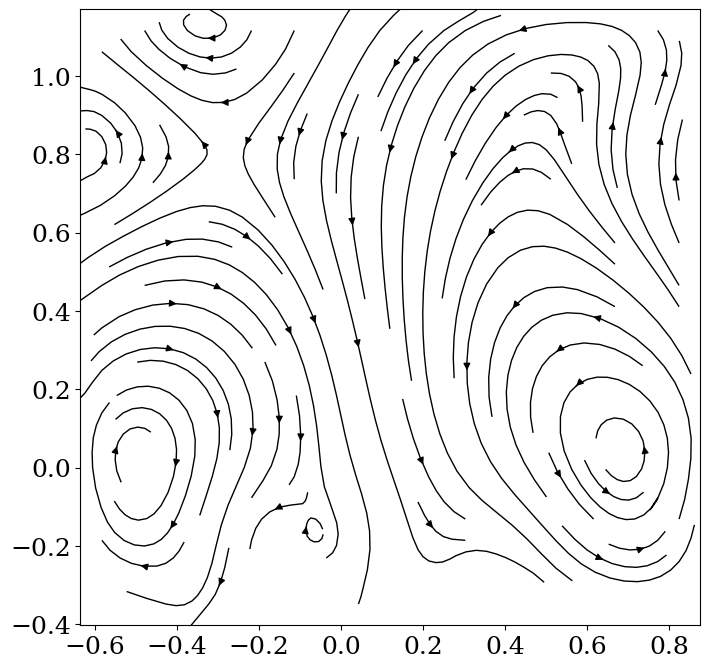

In [3]:

 
r1, func = geom.precompute_line_avg(derivative=0, tol=1e-10, maxiter=40, verbose=True)
v = geom.zero_flow(r1)
condition = lambda t: v
problem = StokesDirichletProblem(geom, condition)
problem.solve(tol=1e-9, maxiter=40)
vel = lambda z: np.abs(problem.evaluate(z))
problem.geometry.plot_stream(ax=plt.gca(), func=lambda z: problem.evaluate(z), apply_mask=True, color='black', linewidth=1)
#plt.quiver(np.real(z), np.imag(z), np.real(r1), np.imag(r1), color="black", scale=8)
#geom.plot(ax=plt.gca(), show_samples=False, color="black", linewidth=3)  
    

### Reparameterisation + Coordinate tfm